In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Backtest — Country Rotation

Long-term portfolio research: 12 country-rotation strategies across 4 families.

**Universe (20+ countries via iShares ETFs):**
- Developed: EWJ EWG EWU EWA EWC EWI EWP EWQ EWL EWD EWN EWS EWH
- Emerging: EWZ EWW EWY EWT MCHI INDA EZA EPOL TUR EIDO
- Blocs (Family 4 only): EFA EEM
- Benchmark: SPY (excluded from rotation universe)
- Cash: BIL

**Strategies tested:**

*Family 1 — Cross-sectional momentum*
- 1a: 12-1 momentum, top 5 EW
- 1b: 6-1 momentum, top 5 EW
- 1c: 3-1 momentum, top 5 EW
- 1d: 12-1 momentum, top 3 EW
- 1e: 12-1 long-short, top 5 / bottom 5

*Family 2 — Time-series momentum*
- 2a: Hold if 12mo return > 0; cash else; EW
- 2b: Hold if price > 200-day SMA; cash else; EW
- 2c: Hold if price > 10-month SMA (Faber); cash else; EW

*Family 3 — Dual momentum (Antonacci)*
- 3a: Top 1 beating BIL; BIL else
- 3b: Top 3 EW beating BIL; BIL fills empty slots
- 3c: Top 5 EW beating BIL; BIL fills empty slots

*Family 4 — EM vs DM rotation*
- 4a: EEM vs EFA, 12mo momentum
- 4b: EEM vs EFA, with BIL filter

**Conventions:**
- Zero slippage (signal comparison)
- Monthly rebalance (last bday of month → first bday of next)
- 12-month minimum history before a country joins rotation universe
- Headline metric: ΔCAGR vs SPY

## Section 0 — Setup

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path

from alpaca.data.timeframe import TimeFrame, TimeFrameUnit
from _shared.loaders_data import fetch_historical_data

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

OUT_DIR = Path("./output")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "daily_equity").mkdir(exist_ok=True)
(OUT_DIR / "trades").mkdir(exist_ok=True)

COUNTRIES_DM = ["EWJ", "EWG", "EWU", "EWA", "EWC", "EWI", "EWP", "EWQ", "EWL", "EWD", "EWN", "EWS", "EWH"]
COUNTRIES_EM = ["EWZ", "EWW", "EWY", "EWT", "MCHI", "INDA", "EZA", "EPOL", "TUR", "EIDO"]
COUNTRIES = COUNTRIES_DM + COUNTRIES_EM
BLOCS = ["EFA", "EEM"]
OTHER = ["SPY", "BIL"]
TICKERS_ALL = COUNTRIES + BLOCS + OTHER

START = datetime(2003, 1, 1)
END = datetime(2025, 5, 1)

print(f"Universe: {len(COUNTRIES)} countries ({len(COUNTRIES_DM)} DM + {len(COUNTRIES_EM)} EM)")
print(f"Total tickers to pull: {len(TICKERS_ALL)}")

Universe: 23 countries (13 DM + 10 EM)
Total tickers to pull: 27


## Section 1 — Data pull & validation

In [2]:
raw = fetch_historical_data(TICKERS_ALL, TimeFrame(1, TimeFrameUnit.Day), START, END)

data = {}
for tk, df in raw.items():
    df = df.copy()
    df.index = df.index.tz_localize(None) if df.index.tz is not None else df.index
    data[tk] = df

print("Date ranges:")
for tk in TICKERS_ALL:
    if tk in data:
        df = data[tk]
        print(f"  {tk:5s}: {df.index.min().date()} → {df.index.max().date()}  ({len(df)} bars)")
    else:
        print(f"  {tk:5s}: NOT RETURNED")

Fetching EWJ...
  2,345 bars
Fetching EWG...
  2,345 bars
Fetching EWU...
  2,345 bars
Fetching EWA...
  2,345 bars
Fetching EWC...
  2,345 bars
Fetching EWI...
  2,345 bars
Fetching EWP...
  2,345 bars
Fetching EWQ...
  2,345 bars
Fetching EWL...
  2,345 bars
Fetching EWD...
  2,345 bars
Fetching EWN...
  2,345 bars
Fetching EWS...
  2,345 bars
Fetching EWH...
  2,345 bars
Fetching EWZ...
  2,345 bars
Fetching EWW...
  2,345 bars
Fetching EWY...
  2,345 bars
Fetching EWT...
  2,345 bars
Fetching MCHI...
  2,345 bars
Fetching INDA...
  2,345 bars
Fetching EZA...
  2,345 bars
Fetching EPOL...
  2,345 bars
Fetching TUR...
  2,345 bars
Fetching EIDO...
  2,345 bars
Fetching EFA...
  2,345 bars
Fetching EEM...
  2,345 bars
Fetching SPY...
  2,345 bars
Fetching BIL...
  2,345 bars
Date ranges:
  EWJ  : 2016-01-04 → 2025-04-30  (2345 bars)
  EWG  : 2016-01-04 → 2025-04-30  (2345 bars)
  EWU  : 2016-01-04 → 2025-04-30  (2345 bars)
  EWA  : 2016-01-04 → 2025-04-30  (2345 bars)
  EWC  : 2016-01

In [3]:
# Unified price frame on business-day grid
bdays = pd.bdate_range(START, END)
px = pd.DataFrame(index=bdays)
for tk, df in data.items():
    s = df["close"].copy()
    s.index = s.index.normalize()
    px[tk] = s.reindex(bdays).ffill(limit=3)

first_valid = px["SPY"].first_valid_index()
px = px.loc[first_valid:]
rets = px.pct_change()

print(f"Unified price frame: {px.index.min().date()} → {px.index.max().date()}  shape={px.shape}")

# Per-ticker availability
print("\nFirst valid date per ticker:")
avail_rows = []
for tk in TICKERS_ALL:
    fv = px[tk].first_valid_index()
    n_valid = px[tk].notna().sum()
    pct = 100 * n_valid / len(px)
    avail_rows.append({"ticker": tk, "first_valid": fv.date() if fv is not None else None,
                       "n_valid": n_valid, "pct_avail": pct})
avail_df = pd.DataFrame(avail_rows).set_index("ticker")
print(avail_df.to_string())

Unified price frame: 2016-01-04 → 2025-05-01  shape=(2434, 27)

First valid date per ticker:
       first_valid  n_valid  pct_avail
ticker                                
EWJ     2016-01-04     2434      100.0
EWG     2016-01-04     2434      100.0
EWU     2016-01-04     2434      100.0
EWA     2016-01-04     2434      100.0
EWC     2016-01-04     2434      100.0
EWI     2016-01-04     2434      100.0
EWP     2016-01-04     2434      100.0
EWQ     2016-01-04     2434      100.0
EWL     2016-01-04     2434      100.0
EWD     2016-01-04     2434      100.0
EWN     2016-01-04     2434      100.0
EWS     2016-01-04     2434      100.0
EWH     2016-01-04     2434      100.0
EWZ     2016-01-04     2434      100.0
EWW     2016-01-04     2434      100.0
EWY     2016-01-04     2434      100.0
EWT     2016-01-04     2434      100.0
MCHI    2016-01-04     2434      100.0
INDA    2016-01-04     2434      100.0
EZA     2016-01-04     2434      100.0
EPOL    2016-01-04     2434      100.0
TUR     20

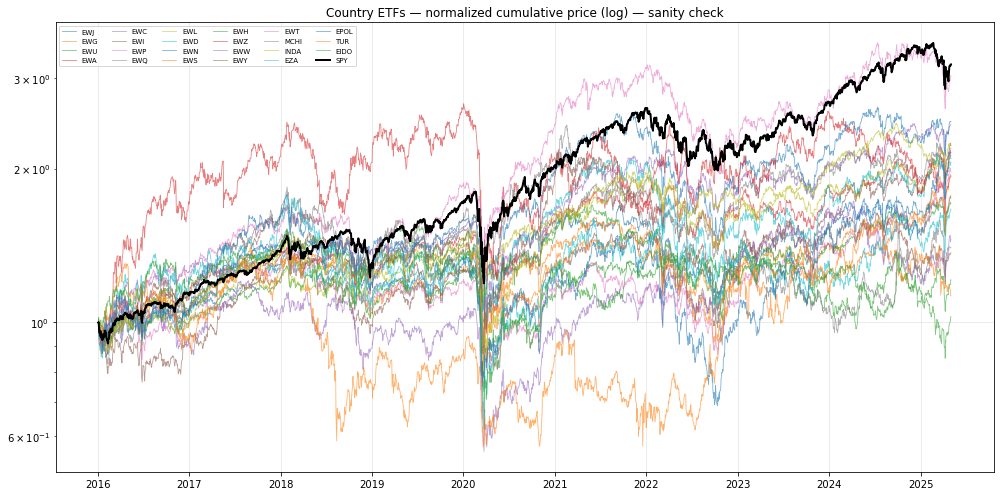

In [4]:
# Quick visual: normalized country price curves
fig, ax = plt.subplots(figsize=(14, 7))
for tk in COUNTRIES:
    s = px[tk].dropna()
    if len(s) == 0:
        continue
    norm = s / s.iloc[0]
    ax.plot(np.asarray(norm.index), np.asarray(norm.values), lw=0.8, alpha=0.6, label=tk)
ax.plot(np.asarray((px["SPY"]/px["SPY"].iloc[0]).index), np.asarray((px["SPY"]/px["SPY"].iloc[0]).values),
        lw=2, color="black", label="SPY")
ax.set_yscale("log")
ax.set_title("Country ETFs — normalized cumulative price (log) — sanity check")
ax.legend(ncol=6, fontsize=7, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Section 2 — Helper Functions

In [5]:
SLIPPAGE_BPS = 0

def metrics_from_returns(daily_ret, name=""):
    r = daily_ret.dropna()
    if len(r) < 2 or r.std() == 0:
        return {"name": name, "sharpe": 0, "cagr": 0, "vol": 0, "max_dd": 0, "calmar": 0, "n_days": len(r)}
    eq = (1 + r).cumprod()
    years = len(r) / 252
    cagr = eq.iloc[-1] ** (1/years) - 1
    vol = r.std() * np.sqrt(252)
    sharpe = r.mean() / r.std() * np.sqrt(252)
    dd = (eq / eq.cummax() - 1).min()
    calmar = cagr / abs(dd) if dd < 0 else np.nan
    return {"name": name, "sharpe": sharpe, "cagr": cagr, "vol": vol, "max_dd": dd, "calmar": calmar, "n_days": len(r)}

def bootstrap_sharpe_pvalue(daily_ret, n_iter=1000, seed=42):
    r = daily_ret.dropna().values
    if len(r) < 30 or r.std() == 0:
        return np.nan
    rng = np.random.RandomState(seed)
    sharpes = np.empty(n_iter)
    for i in range(n_iter):
        sample = rng.choice(r, size=len(r), replace=True)
        sharpes[i] = sample.mean() / sample.std() * np.sqrt(252) if sample.std() > 0 else 0
    return (sharpes <= 0).mean()

def positions_to_returns(weights, returns, slippage_bps=SLIPPAGE_BPS):
    w = weights.shift(1).fillna(0)
    gross = (w * returns).sum(axis=1)
    if slippage_bps > 0:
        turnover = (weights - weights.shift(1)).abs().sum(axis=1).fillna(0)
        cost = turnover * (slippage_bps / 10000)
        return gross - cost
    return gross

def evaluate(name, weights):
    """Single evaluation: filled with SPY on idle days for fair vs-SPY comparison."""
    strat_ret = positions_to_returns(weights, rets[weights.columns].fillna(0))
    active_today = (weights.abs().sum(axis=1) > 0)
    active_yesterday = active_today.shift(1).fillna(False)
    
    # SPY-fill canonical (for like-for-like vs SPY)
    filled_ret = strat_ret.where(active_yesterday, rets["SPY"])
    # Active-only (for signal-quality check)
    active_only_ret = strat_ret.where(active_yesterday)
    
    m_filled = metrics_from_returns(filled_ret, f"{name}_filled")
    m_active = metrics_from_returns(active_only_ret, f"{name}_active")
    p_filled = bootstrap_sharpe_pvalue(filled_ret)
    
    eq_filled = (1 + filled_ret.fillna(0)).cumprod()
    eq_filled.to_frame("equity").to_csv(OUT_DIR / "daily_equity" / f"{name}.csv")
    
    return {
        "name": name,
        "active_days": int(active_today.sum()),
        "pct_active": active_today.mean() * 100,
        "active": m_active,
        "filled": m_filled,
        "p_filled": p_filled,
        "strat_ret": strat_ret,
        "filled_ret": filled_ret,
        "eq_filled": eq_filled,
        "weights": weights,
    }

def print_eval(r, spy_cagr):
    delta = r["filled"]["cagr"] - spy_cagr
    flag = "✅" if delta > 0 else "❌"
    print(f"  Active days: {r['active_days']:>4} ({r['pct_active']:.0f}%)")
    print(f"  Filled:  Sharpe {r['filled']['sharpe']:>5.2f}  CAGR {r['filled']['cagr']:>6.1%}  MaxDD {r['filled']['max_dd']:>6.1%}  ΔCAGR {flag} {delta:+.1%}  p={r['p_filled']:.3f}")

spy_ret_full = rets["SPY"]
spy_eq_full = (1 + spy_ret_full.fillna(0)).cumprod()
spy_metrics = metrics_from_returns(spy_ret_full, "SPY_BH")
SPY_CAGR = spy_metrics["cagr"]
print(f"SPY benchmark: Sharpe {spy_metrics['sharpe']:.2f} | CAGR {SPY_CAGR:.1%} | MaxDD {spy_metrics['max_dd']:.1%}")

SPY benchmark: Sharpe 0.77 | CAGR 12.8% | MaxDD -33.8%


## Section 3 — Momentum signal builder

Standard "N-minus-1" momentum: at month-end T, score country i as `(price[T-1] / price[T-N]) - 1` where N is months. Skipping the last month avoids 1-month reversal contamination.

In [8]:
def monthly_close_panel(prices):
    """Resample daily closes to month-end last business day."""
    return prices.resample("BM").last()

def n_minus_1_momentum(prices, n_months):
    """Returns DataFrame of monthly momentum scores. Score at row T uses prices [T-N-1, T-1] (skip last month)."""
    monthly = monthly_close_panel(prices)
    # numerator: price T-1 (lagged 1 month). denominator: price T-N-1 (lagged N+1 months)
    numerator = monthly.shift(1)
    denominator = monthly.shift(n_months + 1)
    return (numerator / denominator) - 1

def simple_momentum(prices, n_months):
    """Plain N-month momentum without skip-1 (for trend-following filters)."""
    monthly = monthly_close_panel(prices)
    return (monthly / monthly.shift(n_months)) - 1

def available_mask(prices, n_months_required):
    """Mask of countries with at least N months of history at each month-end."""
    monthly = monthly_close_panel(prices)
    # need price N+1 months ago to compute N-minus-1 momentum
    return monthly.shift(n_months_required + 1).notna()

def weights_from_monthly_picks(picks_monthly, daily_index, equal_weight=True):
    """
    Convert a monthly DataFrame of picks (rows=month-ends, cols=tickers, values=1 if picked else 0)
    into a daily-frequency weights DataFrame.
    """
    w_daily = pd.DataFrame(0.0, index=daily_index, columns=picks_monthly.columns)
    for i, month_end in enumerate(picks_monthly.index):
        picks = picks_monthly.iloc[i]
        if picks.sum() == 0:
            continue
        next_start = month_end + pd.offsets.BDay(1)
        if i + 1 < len(picks_monthly.index):
            next_end = picks_monthly.index[i+1]
        else:
            next_end = daily_index[-1]
        mask = (daily_index >= next_start) & (daily_index <= next_end)
        if equal_weight:
            weight = 1.0 / picks.sum()
            for c in picks_monthly.columns:
                if picks[c] == 1:
                    w_daily.loc[mask, c] = weight
    return w_daily

print("Signal builders loaded.")

Signal builders loaded.


## Section 4 — Family 1: Cross-Sectional Momentum

In [9]:
results = {}

def xsec_momentum(prices, n_months, top_k):
    """Long-only top-K cross-sectional momentum."""
    mom = n_minus_1_momentum(prices[COUNTRIES], n_months)
    avail = available_mask(prices[COUNTRIES], n_months)
    # Mask scores to only available countries
    mom_masked = mom.where(avail)
    
    picks = pd.DataFrame(0, index=mom_masked.index, columns=mom_masked.columns)
    for i, dt in enumerate(mom_masked.index):
        row = mom_masked.iloc[i].dropna()
        if len(row) < top_k:
            continue
        top = row.nlargest(top_k).index
        picks.loc[dt, top] = 1
    return picks

def xsec_long_short(prices, n_months, top_k, bottom_k):
    """Long top-K, short bottom-K. Returns weights directly (not picks)."""
    mom = n_minus_1_momentum(prices[COUNTRIES], n_months)
    avail = available_mask(prices[COUNTRIES], n_months)
    mom_masked = mom.where(avail)
    
    w_monthly = pd.DataFrame(0.0, index=mom_masked.index, columns=mom_masked.columns)
    for i, dt in enumerate(mom_masked.index):
        row = mom_masked.iloc[i].dropna()
        if len(row) < top_k + bottom_k:
            continue
        top = row.nlargest(top_k).index
        bot = row.nsmallest(bottom_k).index
        w_monthly.loc[dt, top] = 0.5 / top_k
        w_monthly.loc[dt, bot] = -0.5 / bottom_k
    return w_monthly

def lift_monthly_to_daily(monthly_w, daily_index):
    """Lift monthly weights to daily (forward-fill until next month-end)."""
    w_daily = pd.DataFrame(0.0, index=daily_index, columns=monthly_w.columns)
    for i, month_end in enumerate(monthly_w.index):
        next_start = month_end + pd.offsets.BDay(1)
        next_end = monthly_w.index[i+1] if i+1 < len(monthly_w.index) else daily_index[-1]
        mask = (daily_index >= next_start) & (daily_index <= next_end)
        for c in monthly_w.columns:
            w_daily.loc[mask, c] = monthly_w.iloc[i][c]
    return w_daily

# 1a: 12-1 momentum, top 5 EW
picks_1a = xsec_momentum(px, n_months=12, top_k=5)
w_1a = weights_from_monthly_picks(picks_1a, px.index)
print("=== xsec_mom_12-1_top5 ===")
r = evaluate("xsec_mom_12-1_top5", w_1a); print_eval(r, SPY_CAGR); results["xsec_mom_12-1_top5"] = r

# 1b: 6-1 momentum, top 5 EW
picks_1b = xsec_momentum(px, n_months=6, top_k=5)
w_1b = weights_from_monthly_picks(picks_1b, px.index)
print("\n=== xsec_mom_6-1_top5 ===")
r = evaluate("xsec_mom_6-1_top5", w_1b); print_eval(r, SPY_CAGR); results["xsec_mom_6-1_top5"] = r

# 1c: 3-1 momentum, top 5 EW
picks_1c = xsec_momentum(px, n_months=3, top_k=5)
w_1c = weights_from_monthly_picks(picks_1c, px.index)
print("\n=== xsec_mom_3-1_top5 ===")
r = evaluate("xsec_mom_3-1_top5", w_1c); print_eval(r, SPY_CAGR); results["xsec_mom_3-1_top5"] = r

# 1d: 12-1 momentum, top 3 EW
picks_1d = xsec_momentum(px, n_months=12, top_k=3)
w_1d = weights_from_monthly_picks(picks_1d, px.index)
print("\n=== xsec_mom_12-1_top3 ===")
r = evaluate("xsec_mom_12-1_top3", w_1d); print_eval(r, SPY_CAGR); results["xsec_mom_12-1_top3"] = r

# 1e: 12-1 long-short, top 5 / bottom 5
w_1e_monthly = xsec_long_short(px, n_months=12, top_k=5, bottom_k=5)
w_1e = lift_monthly_to_daily(w_1e_monthly, px.index)
print("\n=== xsec_mom_12-1_LS5x5 ===")
r = evaluate("xsec_mom_12-1_LS5x5", w_1e); print_eval(r, SPY_CAGR); results["xsec_mom_12-1_LS5x5"] = r

=== xsec_mom_12-1_top5 ===
  Active days: 2132 (88%)
  Filled:  Sharpe  0.47  CAGR   7.0%  MaxDD -44.3%  ΔCAGR ❌ -5.8%  p=0.081

=== xsec_mom_6-1_top5 ===
  Active days: 2261 (93%)
  Filled:  Sharpe  0.46  CAGR   7.1%  MaxDD -47.5%  ΔCAGR ❌ -5.7%  p=0.072

=== xsec_mom_3-1_top5 ===
  Active days: 2327 (96%)
  Filled:  Sharpe  0.25  CAGR   3.0%  MaxDD -49.7%  ΔCAGR ❌ -9.8%  p=0.215

=== xsec_mom_12-1_top3 ===
  Active days: 2132 (88%)
  Filled:  Sharpe  0.41  CAGR   6.1%  MaxDD -40.4%  ΔCAGR ❌ -6.7%  p=0.099

=== xsec_mom_12-1_LS5x5 ===
  Active days: 2132 (88%)
  Filled:  Sharpe  0.02  CAGR  -0.1%  MaxDD -21.7%  ΔCAGR ❌ -12.9%  p=0.470


## Section 5 — Family 2: Time-Series Momentum (per-country trend following)

In [10]:
def ts_momentum_12mo(prices):
    """Hold country if 12-month return > 0. EW across all 'on' countries; BIL fills if none."""
    mom = simple_momentum(prices[COUNTRIES], n_months=12)
    avail = available_mask(prices[COUNTRIES], n_months_required=12)
    mom_masked = mom.where(avail)
    picks = (mom_masked > 0).astype(int)
    return picks

def ts_sma_filter(prices, window_days):
    """Hold country if daily price > SMA. Aggregated to month-end signal."""
    sma = prices[COUNTRIES].rolling(window_days).mean()
    above = (prices[COUNTRIES] > sma).astype(int)
    # snapshot at month-ends
    monthly_signal = above.resample("BE").last()
    return monthly_signal

def ts_sma_monthly(prices, n_months):
    """Faber-style: hold country if monthly price > N-month SMA of monthly prices."""
    monthly = monthly_close_panel(prices[COUNTRIES])
    sma = monthly.rolling(n_months).mean()
    above = (monthly > sma).astype(int)
    return above

def picks_to_weights_with_bil_fill(picks, daily_index):
    """Convert picks to weights including BIL when no countries qualify."""
    cols = list(picks.columns) + ["BIL"]
    w_daily = pd.DataFrame(0.0, index=daily_index, columns=cols)
    for i, month_end in enumerate(picks.index):
        row = picks.iloc[i]
        next_start = month_end + pd.offsets.BDay(1)
        next_end = picks.index[i+1] if i+1 < len(picks.index) else daily_index[-1]
        mask = (daily_index >= next_start) & (daily_index <= next_end)
        n_on = int(row.sum())
        if n_on == 0:
            w_daily.loc[mask, "BIL"] = 1.0
        else:
            weight = 1.0 / n_on
            for c in picks.columns:
                if row[c] == 1:
                    w_daily.loc[mask, c] = weight
    return w_daily

# 2a: 12-month positive momentum filter
picks_2a = ts_momentum_12mo(px)
w_2a = picks_to_weights_with_bil_fill(picks_2a, px.index)
print("=== ts_mom_12mo_positive ===")
r = evaluate("ts_mom_12mo_positive", w_2a); print_eval(r, SPY_CAGR); results["ts_mom_12mo_positive"] = r

# 2b: 200-day SMA filter (daily price)
picks_2b = ts_sma_filter(px, window_days=200)
# only keep countries that have 200d of history
avail_200 = available_mask(px[COUNTRIES], n_months_required=10)  # ~200 trading days = 10 months
picks_2b = picks_2b.where(avail_200, 0)
w_2b = picks_to_weights_with_bil_fill(picks_2b, px.index)
print("\n=== ts_sma200_daily ===")
r = evaluate("ts_sma200_daily", w_2b); print_eval(r, SPY_CAGR); results["ts_sma200_daily"] = r

# 2c: 10-month SMA (Faber)
picks_2c = ts_sma_monthly(px, n_months=10)
avail_10mo = available_mask(px[COUNTRIES], n_months_required=10)
picks_2c = picks_2c.where(avail_10mo, 0)
w_2c = picks_to_weights_with_bil_fill(picks_2c, px.index)
print("\n=== ts_sma10mo_faber ===")
r = evaluate("ts_sma10mo_faber", w_2c); print_eval(r, SPY_CAGR); results["ts_sma10mo_faber"] = r

=== ts_mom_12mo_positive ===
  Active days: 2414 (99%)
  Filled:  Sharpe  0.23  CAGR   2.5%  MaxDD -50.9%  ΔCAGR ❌ -10.3%  p=0.236


ValueError: Invalid frequency: BE

## Section 6 — Family 3: Dual Momentum (Antonacci)

In [11]:
def dual_momentum(prices, top_k):
    """
    Hold top-K countries that beat BIL's 12mo return. BIL fills remaining slots.
    If no country beats BIL → 100% BIL.
    """
    mom_countries = simple_momentum(prices[COUNTRIES], n_months=12)
    mom_bil = simple_momentum(prices[["BIL"]], n_months=12)
    avail = available_mask(prices[COUNTRIES], n_months_required=12)
    
    cols = COUNTRIES + ["BIL"]
    monthly_picks_dollars = pd.DataFrame(0.0, index=mom_countries.index, columns=cols)
    
    for i, dt in enumerate(mom_countries.index):
        bil_t = mom_bil.iloc[i, 0] if i < len(mom_bil) else np.nan
        if pd.isna(bil_t):
            continue
        row = mom_countries.iloc[i].where(avail.iloc[i]).dropna()
        eligible = row[row > bil_t]
        if len(eligible) == 0:
            monthly_picks_dollars.loc[dt, "BIL"] = 1.0
            continue
        n_picks = min(top_k, len(eligible))
        top = eligible.nlargest(n_picks).index
        weight_each = 1.0 / top_k  # always divide by target K, BIL fills empty slots
        for c in top:
            monthly_picks_dollars.loc[dt, c] = weight_each
        # BIL fills the empty slots if eligible < top_k
        empty_slots = top_k - n_picks
        if empty_slots > 0:
            monthly_picks_dollars.loc[dt, "BIL"] = empty_slots * weight_each
    return monthly_picks_dollars

# 3a: Top 1
w_3a_m = dual_momentum(px, top_k=1)
w_3a = lift_monthly_to_daily(w_3a_m, px.index)
print("=== dual_mom_top1 ===")
r = evaluate("dual_mom_top1", w_3a); print_eval(r, SPY_CAGR); results["dual_mom_top1"] = r

# 3b: Top 3 EW + BIL fills empty
w_3b_m = dual_momentum(px, top_k=3)
w_3b = lift_monthly_to_daily(w_3b_m, px.index)
print("\n=== dual_mom_top3 ===")
r = evaluate("dual_mom_top3", w_3b); print_eval(r, SPY_CAGR); results["dual_mom_top3"] = r

# 3c: Top 5 EW + BIL fills empty
w_3c_m = dual_momentum(px, top_k=5)
w_3c = lift_monthly_to_daily(w_3c_m, px.index)
print("\n=== dual_mom_top5 ===")
r = evaluate("dual_mom_top5", w_3c); print_eval(r, SPY_CAGR); results["dual_mom_top5"] = r

=== dual_mom_top1 ===
  Active days: 2152 (88%)
  Filled:  Sharpe  0.37  CAGR   6.3%  MaxDD -41.7%  ΔCAGR ❌ -6.5%  p=0.123

=== dual_mom_top3 ===
  Active days: 2152 (88%)
  Filled:  Sharpe  0.26  CAGR   3.1%  MaxDD -47.0%  ΔCAGR ❌ -9.7%  p=0.202

=== dual_mom_top5 ===
  Active days: 2152 (88%)
  Filled:  Sharpe  0.25  CAGR   2.9%  MaxDD -48.8%  ΔCAGR ❌ -9.9%  p=0.218


## Section 7 — Family 4: EM vs DM Rotation

In [12]:
def em_vs_dm(prices, with_bil_filter=False):
    """Hold whichever of EEM/EFA has higher 12mo return. Optional: cash if both lose to BIL."""
    mom = simple_momentum(prices[["EEM", "EFA", "BIL"]], n_months=12)
    avail = mom["EEM"].notna() & mom["EFA"].notna()
    cols = ["EEM", "EFA", "BIL"]
    monthly_w = pd.DataFrame(0.0, index=mom.index, columns=cols)
    
    for i, dt in enumerate(mom.index):
        if not avail.iloc[i]:
            continue
        eem_r = mom["EEM"].iloc[i]
        efa_r = mom["EFA"].iloc[i]
        bil_r = mom["BIL"].iloc[i] if not pd.isna(mom["BIL"].iloc[i]) else 0
        
        winner = "EEM" if eem_r > efa_r else "EFA"
        winner_r = max(eem_r, efa_r)
        
        if with_bil_filter and winner_r < bil_r:
            monthly_w.loc[dt, "BIL"] = 1.0
        else:
            monthly_w.loc[dt, winner] = 1.0
    return monthly_w

# 4a: pure EM vs DM
w_4a_m = em_vs_dm(px, with_bil_filter=False)
w_4a = lift_monthly_to_daily(w_4a_m, px.index)
print("=== em_dm_rotation ===")
r = evaluate("em_dm_rotation", w_4a); print_eval(r, SPY_CAGR); results["em_dm_rotation"] = r

# 4b: with BIL filter
w_4b_m = em_vs_dm(px, with_bil_filter=True)
w_4b = lift_monthly_to_daily(w_4b_m, px.index)
print("\n=== em_dm_rotation_bilfilter ===")
r = evaluate("em_dm_rotation_bilfilter", w_4b); print_eval(r, SPY_CAGR); results["em_dm_rotation_bilfilter"] = r

=== em_dm_rotation ===
  Active days: 2152 (88%)
  Filled:  Sharpe  0.43  CAGR   6.3%  MaxDD -41.0%  ΔCAGR ❌ -6.5%  p=0.093

=== em_dm_rotation_bilfilter ===
  Active days: 2152 (88%)
  Filled:  Sharpe  0.39  CAGR   4.4%  MaxDD -26.2%  ΔCAGR ❌ -8.4%  p=0.110


## Section 8 — Master Comparison

In [13]:
rows = []
for name, r in results.items():
    rows.append({
        "strategy": name,
        "delta_cagr": r["filled"]["cagr"] - SPY_CAGR,
        "cagr": r["filled"]["cagr"],
        "sharpe": r["filled"]["sharpe"],
        "maxdd": r["filled"]["max_dd"],
        "calmar": r["filled"]["calmar"],
        "p_value": r["p_filled"],
        "pct_active": r["pct_active"],
    })
summary = pd.DataFrame(rows).set_index("strategy").sort_values("delta_cagr", ascending=False)
summary.loc["SPY_BH"] = {"delta_cagr": 0, "cagr": SPY_CAGR, "sharpe": spy_metrics["sharpe"],
                          "maxdd": spy_metrics["max_dd"], "calmar": spy_metrics["calmar"],
                          "p_value": np.nan, "pct_active": 100}

disp = summary.copy()
disp["delta_cagr"] = disp["delta_cagr"].map(lambda x: f"{x:+.1%}" if pd.notna(x) else "")
for c in ["cagr", "maxdd"]:
    disp[c] = disp[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
for c in ["sharpe", "calmar"]:
    disp[c] = disp[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "")
disp["p_value"] = disp["p_value"].map(lambda x: f"{x:.3f}" if pd.notna(x) else "")
disp["pct_active"] = disp["pct_active"].map(lambda x: f"{x:.0f}%")

print("=" * 110)
print("COUNTRY ROTATION SUMMARY — sorted by ΔCAGR vs SPY")
print("=" * 110)
print(disp.to_string())

COUNTRY ROTATION SUMMARY — sorted by ΔCAGR vs SPY
                         delta_cagr   cagr sharpe   maxdd calmar p_value pct_active
strategy                                                                           
xsec_mom_6-1_top5             -5.7%   7.1%   0.46  -47.5%   0.15   0.072        93%
xsec_mom_12-1_top5            -5.8%   7.0%   0.47  -44.3%   0.16   0.081        88%
em_dm_rotation                -6.5%   6.3%   0.43  -41.0%   0.15   0.093        88%
dual_mom_top1                 -6.5%   6.3%   0.37  -41.7%   0.15   0.123        88%
xsec_mom_12-1_top3            -6.7%   6.1%   0.41  -40.4%   0.15   0.099        88%
em_dm_rotation_bilfilter      -8.4%   4.4%   0.39  -26.2%   0.17   0.110        88%
dual_mom_top3                 -9.7%   3.1%   0.26  -47.0%   0.07   0.202        88%
xsec_mom_3-1_top5             -9.8%   3.0%   0.25  -49.7%   0.06   0.215        96%
dual_mom_top5                 -9.9%   2.9%   0.25  -48.8%   0.06   0.218        88%
ts_mom_12mo_positive      

In [14]:
# Regime-conditional CAGR
covid_window = (px.index >= "2020-02-15") & (px.index <= "2020-08-31")
bear_2022 = (px.index >= "2022-01-01") & (px.index <= "2022-12-31")

def cagr_subperiod(daily_ret, mask):
    r = daily_ret[~mask].dropna()
    if len(r) < 30: return np.nan
    eq = (1 + r).cumprod()
    yrs = len(r) / 252
    return eq.iloc[-1] ** (1/yrs) - 1

rows_r = []
for name, r in results.items():
    fr = r["filled_ret"]
    rows_r.append({
        "strategy": name,
        "cagr_full": r["filled"]["cagr"],
        "cagr_ex_covid": cagr_subperiod(fr, covid_window),
        "cagr_ex_2022": cagr_subperiod(fr, bear_2022),
        "cagr_ex_both": cagr_subperiod(fr, covid_window | bear_2022),
    })
regime_df = pd.DataFrame(rows_r).set_index("strategy").sort_values("cagr_full", ascending=False)
regime_df.loc["SPY_BH"] = {
    "cagr_full": SPY_CAGR,
    "cagr_ex_covid": cagr_subperiod(spy_ret_full, covid_window),
    "cagr_ex_2022": cagr_subperiod(spy_ret_full, bear_2022),
    "cagr_ex_both": cagr_subperiod(spy_ret_full, covid_window | bear_2022),
}
disp_r = regime_df.copy()
for c in disp_r.columns:
    disp_r[c] = disp_r[c].map(lambda x: f"{x:.1%}" if pd.notna(x) else "")
print("=" * 90)
print("REGIME-CONDITIONAL CAGR")
print("=" * 90)
print(disp_r.to_string())

REGIME-CONDITIONAL CAGR
                         cagr_full cagr_ex_covid cagr_ex_2022 cagr_ex_both
strategy                                                                  
xsec_mom_6-1_top5             7.1%          8.3%         8.3%         9.7%
xsec_mom_12-1_top5            7.0%          7.5%         9.2%        10.0%
em_dm_rotation                6.3%          6.9%         9.1%         9.9%
dual_mom_top1                 6.3%          6.8%         4.5%         5.0%
xsec_mom_12-1_top3            6.1%          5.8%         8.3%         8.1%
em_dm_rotation_bilfilter      4.4%          5.5%         6.5%         7.9%
dual_mom_top3                 3.1%          3.7%         4.3%         5.0%
xsec_mom_3-1_top5             3.0%          4.3%         5.2%         6.8%
dual_mom_top5                 2.9%          4.7%         4.7%         7.0%
ts_mom_12mo_positive          2.5%          3.4%         3.4%         4.4%
xsec_mom_12-1_LS5x5          -0.1%         -0.4%         0.5%         0.2%
S

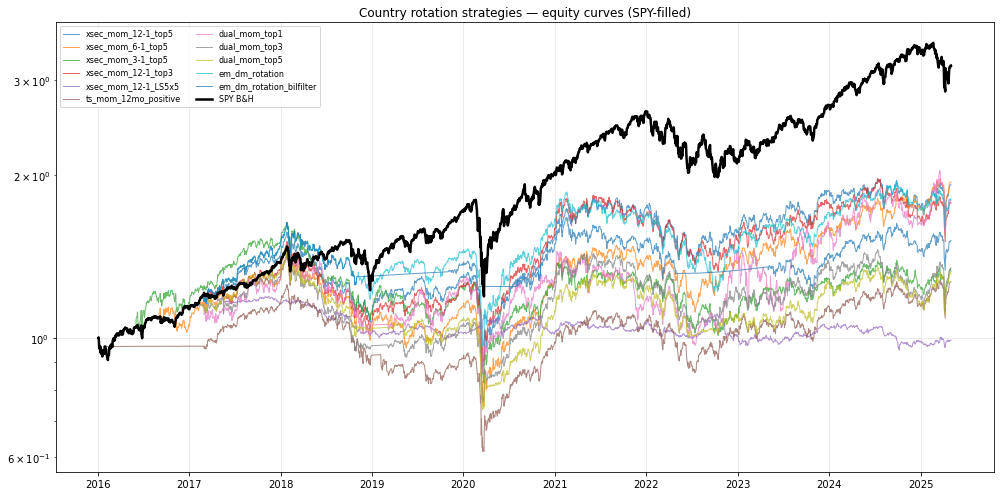

In [15]:
# Equity curves
fig, ax = plt.subplots(figsize=(14, 7))
for name, r in results.items():
    eq = r["eq_filled"]
    ax.plot(np.asarray(eq.index), np.asarray(eq.values), lw=1.0, alpha=0.7, label=name)
ax.plot(np.asarray(spy_eq_full.index), np.asarray(spy_eq_full.values), lw=2.5, color="black", label="SPY B&H")
ax.set_yscale("log")
ax.set_title("Country rotation strategies — equity curves (SPY-filled)")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

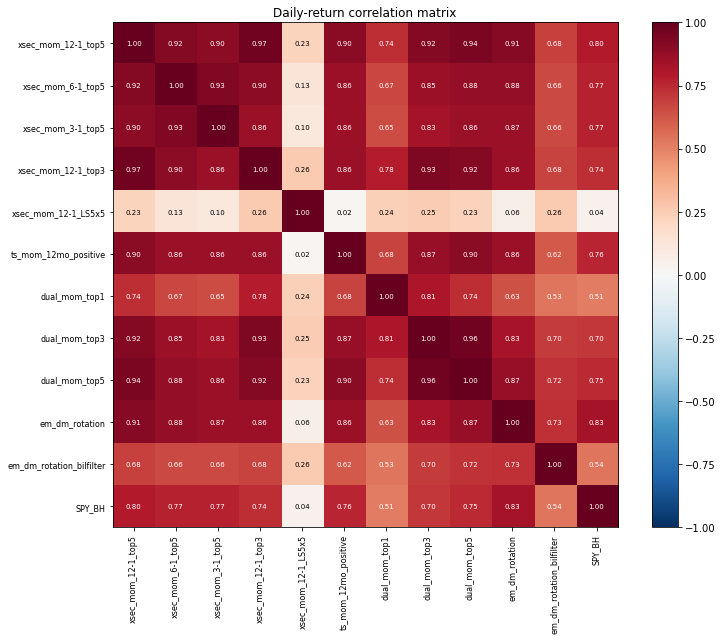

In [16]:
# Correlation matrix of filled returns
ret_df = pd.DataFrame({name: r["filled_ret"] for name, r in results.items()})
ret_df["SPY_BH"] = spy_ret_full
corr = ret_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.iloc[i,j]) > 0.5 else "black")
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title("Daily-return correlation matrix")
plt.tight_layout(); plt.show()

In [ ]:
# Save outputs
import json
summary.to_csv(OUT_DIR / "country_rotation_summary.csv")
regime_df.to_csv(OUT_DIR / "country_rotation_regime.csv")

out = {}
for name, r in results.items():
    out[name] = {
        "active_days": r["active_days"],
        "pct_active": r["pct_active"],
        "cagr": float(r["filled"]["cagr"]),
        "sharpe": float(r["filled"]["sharpe"]),
        "max_dd": float(r["filled"]["max_dd"]),
        "p_value": float(r["p_filled"]) if pd.notna(r["p_filled"]) else None,
    }
with open(OUT_DIR / "country_rotation_summary.json", "w") as f:
    json.dump(out, f, indent=2)
print(f"Saved → {OUT_DIR}/country_rotation_*.{{csv,json}}")

---

## Findings template (fill after running)

**Strategies beating SPY (positive ΔCAGR):**
- _(populate)_

**Best diversifiers (lowest correlation with SPY):**
- _(populate)_

**Best risk-adjusted (Sharpe + MaxDD):**
- _(populate)_

**Candidates for Portfolio C:**
- _(populate)_